# Act 4 — Hidden Damage: Promotions Running on Empty Shelves

> **Câu hỏi:** Promotions có đang kích hoạt trong giai đoạn stockout — tạo ra demand không thể đáp ứng, gây thiệt hại cả revenue lẫn customer experience?

**Dữ liệu:** oat.parquet · promotions.csv · inventory.csv · reviews.csv
**Luận điểm:** Công ty trả tiền để stimulate demand (qua discount) đúng lúc supply bằng 0 — double damage làm lãng phí promotion budget và tổn hại customer trust.

In [1]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
from scipy.stats import mannwhitneyu

np.random.seed(42)
random.seed(42)

plt.rcParams.update({
    "figure.facecolor":  "#fafafa",
    "axes.facecolor":    "#fafafa",
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         11,
})

PALETTE = {
    "positive": "#2d6a4f",
    "negative": "#c1121f",
    "promo":    "#e76f51",
    "organic":  "#457b9d",
    "neutral":  "#adb5bd",
    "warning":  "#e9c46a",
    "gp":       "#2d6a4f",
    "cogs":     "#adb5bd",
    "discount": "#c1121f",
    "returns":  "#e9c46a",
}

def save_chart(fig, path, dpi=150):
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor())
    sz = Path(path).stat().st_size // 1024
    print(f"Saved: {path}  ({sz} KB)")
    if sz < 100:
        print(f"  CANH BAO: PNG nho hon 100KB ({sz} KB)")

Path("outputs/charts").mkdir(parents=True, exist_ok=True)
Path("outputs/tables").mkdir(parents=True, exist_ok=True)
print("Config loaded.")

Config loaded.


In [2]:
oat = pd.read_parquet("oat.parquet")
oat["order_date"] = pd.to_datetime(oat["order_date"])

promotions = pd.read_csv("data/promotions.csv", parse_dates=["start_date","end_date"])
inventory  = pd.read_csv("data/inventory.csv",  parse_dates=["snapshot_date"])
reviews    = pd.read_csv("data/reviews.csv",    parse_dates=["review_date"])

print(f"OAT: {len(oat):,} rows")
print(f"Promotions: {len(promotions)}  |  Inventory: {len(inventory)}  |  Reviews: {len(reviews)}")
display(promotions.dropna(subset=["applicable_category"])
        [["promo_id","promo_name","start_date","end_date","applicable_category"]].head(10))

OAT: 714,669 rows
Promotions: 50  |  Inventory: 60247  |  Reviews: 113551


,promo_id,promo_name,start_date,end_date,applicable_category
4,PROMO-0005,Urban Blowout 2013,2013-07-30,2013-09-02,Streetwear
5,PROMO-0006,Rural Special 2013,2013-01-31,2013-03-01,Outdoor
14,PROMO-0015,Urban Blowout 2015,2015-07-30,2015-09-02,Streetwear
15,PROMO-0016,Rural Special 2015,2015-01-30,2015-03-01,Outdoor
24,PROMO-0025,Urban Blowout 2017,2017-07-30,2017-09-02,Streetwear
25,PROMO-0026,Rural Special 2017,2017-01-30,2017-03-01,Outdoor
34,PROMO-0035,Urban Blowout 2019,2019-07-30,2019-09-02,Streetwear
35,PROMO-0036,Rural Special 2019,2019-01-30,2019-03-01,Outdoor
44,PROMO-0045,Urban Blowout 2021,2021-07-30,2021-09-02,Streetwear
45,PROMO-0046,Rural Special 2021,2021-01-30,2021-03-01,Outdoor


In [3]:
# Tim cac su kien Promo x Stockout overlap
promo_cats = promotions.dropna(subset=["applicable_category"])["applicable_category"].unique()
print(f"Categories co promotion: {list(promo_cats)}")

overlaps = []
for _, promo in promotions.iterrows():
    cat = promo["applicable_category"]
    if pd.isna(cat): continue
    inv_match = inventory[
        (inventory["category"] == cat) &
        (inventory["snapshot_date"] >= promo["start_date"]) &
        (inventory["snapshot_date"] <= promo["end_date"]) &
        (inventory["stockout_flag"] == 1)
    ].copy()
    if len(inv_match) > 0:
        inv_match["promo_id"]   = promo["promo_id"]
        inv_match["promo_name"] = promo["promo_name"]
        overlaps.append(inv_match)

if overlaps:
    overlap_df = pd.concat(overlaps, ignore_index=True)
    print(f"Found {len(overlap_df)} overlap events across {overlap_df['promo_id'].nunique()} promotions")
else:
    overlap_df = pd.DataFrame()
    print("No overlaps found")

Categories co promotion: ['Streetwear', 'Outdoor']
Found 2885 overlap events across 10 promotions


In [4]:
# Uoc tinh lost revenue -- optimised: pre-aggregate OAT theo (category, thang)
if not overlap_df.empty:
    oat["_ym"] = oat["order_date"].dt.to_period("M")
    monthly_gp = (oat.groupby(["category","_ym"])["gross_profit"]
                  .sum().reset_index()
                  .rename(columns={"gross_profit":"monthly_gp"}))
    monthly_gp["daily_gp"] = monthly_gp["monthly_gp"] / 30.0

    def est_lost(row):
        snap_period = pd.Period(row["snapshot_date"], "M")
        prev_periods = [snap_period - i for i in range(1, 4)]
        rows = monthly_gp[
            (monthly_gp["category"] == row["category"]) &
            (monthly_gp["_ym"].isin(prev_periods))
        ]
        if rows.empty: return 0.0
        return rows["daily_gp"].mean() * row.get("stockout_days", 1)

    overlap_df["estimated_lost_revenue"] = overlap_df.apply(est_lost, axis=1)
    total_lost = overlap_df["estimated_lost_revenue"].sum()
    avg_fill   = overlap_df["fill_rate"].mean() if "fill_rate" in overlap_df.columns else float("nan")
    print(f"Total double damage events   : {len(overlap_df)}")
    print(f"Total estimated lost revenue : {total_lost:,.0f} VND")
    print(f"Avg fill_rate during overlap : {avg_fill:.1f}%")
    display(overlap_df.sort_values("estimated_lost_revenue", ascending=False).head(10))
else:
    total_lost, avg_fill = 0.0, float("nan")

Total double damage events   : 2885
Total estimated lost revenue : 2,095,650,676 VND
Avg fill_rate during overlap : 0.9%


,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month,promo_id,promo_name,estimated_lost_revenue
701,2015-08-31,660,15,78,66,28,6.8,0.0667,1,0,0,0.8148,SaigonFlex UC-25,Streetwear,Everyday,2015,8,PROMO-0015,Urban Blowout 2015,1.945088e+07
618,2015-08-31,409,53,185,147,26,10.8,0.1333,1,0,0,0.7350,SaigonFlex UM-14,Streetwear,Balanced,2015,8,PROMO-0015,Urban Blowout 2015,1.806153e+07
1209,2017-08-31,425,15,36,30,21,15.0,0.3000,1,0,0,0.6667,SaigonFlex UM-30,Streetwear,Balanced,2017,8,PROMO-0025,Urban Blowout 2017,1.521362e+07
627,2015-08-31,438,7,26,22,19,9.5,0.3667,1,0,0,0.7586,SaigonFlex UM-43,Streetwear,Balanced,2015,8,PROMO-0015,Urban Blowout 2015,1.319881e+07
270,2013-08-31,2049,25,74,63,23,11.9,0.2333,1,0,0,0.7159,UrbanVN UE-09,Streetwear,Performance,2013,8,PROMO-0005,Urban Blowout 2013,1.206248e+07
1223,2017-08-31,473,6,20,17,14,10.6,0.5333,1,0,0,0.7391,SaigonFlex UM-78,Streetwear,Balanced,2017,8,PROMO-0025,Urban Blowout 2017,1.014241e+07
1237,2017-08-31,504,14,28,23,14,18.3,0.5333,1,0,0,0.6216,SaigonFlex UM-09,Streetwear,Balanced,2017,8,PROMO-0025,Urban Blowout 2017,1.014241e+07
1206,2017-08-31,420,32,53,45,14,21.3,0.5333,1,0,0,0.5844,SaigonFlex UM-25,Streetwear,Balanced,2017,8,PROMO-0025,Urban Blowout 2017,1.014241e+07
1944,2019-08-31,959,10,32,26,22,11.5,0.2667,1,0,0,0.7222,HanoiStreet UC-22,Streetwear,Everyday,2019,8,PROMO-0035,Urban Blowout 2019,8.741283e+06
849,2015-07-31,2067,34,45,35,9,29.1,0.7000,1,0,0,0.5072,UrbanVN UC-02,Streetwear,Everyday,2015,7,PROMO-0015,Urban Blowout 2015,8.670411e+06


In [5]:
# Review rating check sau su kien stockout
rating_delta = float("nan")
avg_pre_rating = avg_post_rating = float("nan")
if not overlap_df.empty:
    try:
        reviews_cat = reviews.merge(
            oat[["order_id","product_id","category"]].drop_duplicates(),
            on=["order_id","product_id"], how="left",
        )
        pre_ratings, post_ratings = [], []
        for _, ev in overlap_df.drop_duplicates(subset=["promo_id","category","snapshot_date"]).iterrows():
            snap, cat = ev["snapshot_date"], ev["category"]
            pre  = reviews_cat[
                (reviews_cat["category"] == cat) &
                (reviews_cat["review_date"] >= snap - pd.Timedelta(days=30)) &
                (reviews_cat["review_date"] <  snap)
            ]["rating"]
            post = reviews_cat[
                (reviews_cat["category"] == cat) &
                (reviews_cat["review_date"] >= snap + pd.Timedelta(days=7)) &
                (reviews_cat["review_date"] <= snap + pd.Timedelta(days=14))
            ]["rating"]
            if len(pre):  pre_ratings.extend(pre.tolist())
            if len(post): post_ratings.extend(post.tolist())
        if pre_ratings and post_ratings:
            avg_pre_rating  = np.mean(pre_ratings)
            avg_post_rating = np.mean(post_ratings)
            rating_delta    = avg_post_rating - avg_pre_rating
            print(f"Avg review rating before stockout event : {avg_pre_rating:.2f} stars")
            print(f"Avg review rating after stockout event  : {avg_post_rating:.2f} stars")
            print(f"Rating delta                            : {rating_delta:+.2f} stars")
        else:
            print("Insufficient review data for rating delta")
    except Exception as e:
        print(f"Rating check skipped: {e}")

Avg review rating before stockout event : 3.94 stars
Avg review rating after stockout event  : 3.97 stars
Rating delta                            : +0.03 stars


Saved: outputs/charts/chart6_promo_stockout_timeline.png  (124 KB)


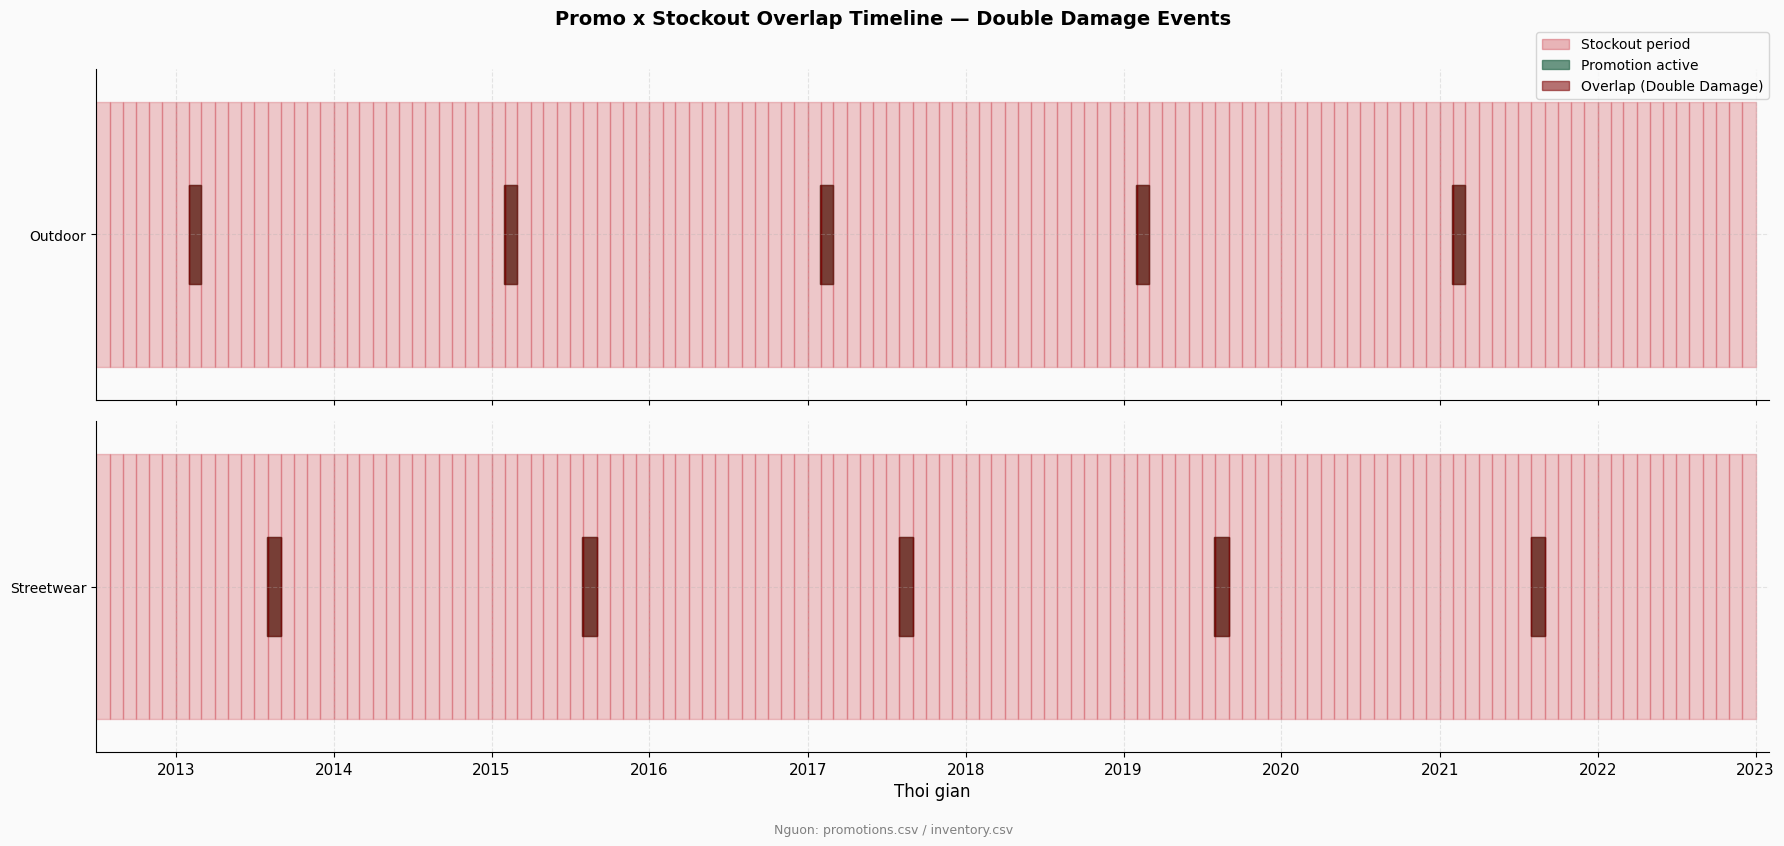

Saved: outputs/tables/promo_stockout_overlaps.csv


In [6]:
# Chart 6 — Promo x Stockout Timeline
try:
    inventory["year_month"] = inventory["snapshot_date"].dt.to_period("M")
    inv_monthly = (inventory.groupby(["category","year_month"])
                             .agg(has_stockout  =("stockout_flag","max"),
                                  avg_fill_rate =("fill_rate","mean"))
                             .reset_index())

    categories = sorted(promo_cats)
    n_cats = len(categories)
    time_min = pd.Timestamp(oat["order_date"].min().date().replace(day=1))
    time_max = pd.Timestamp(oat["order_date"].max().date()) + pd.DateOffset(months=1)

    fig, axes = plt.subplots(n_cats, 1, figsize=(18, max(3*n_cats+2, 8)), sharex=True)
    fig.set_facecolor("#fafafa")
    if n_cats == 1: axes = [axes]

    legend_handles = [
        mpatches.Patch(color=PALETTE["negative"], alpha=0.30, label="Stockout period"),
        mpatches.Patch(color=PALETTE["positive"], alpha=0.70, label="Promotion active"),
        mpatches.Patch(color="#7d0000",           alpha=0.55, label="Overlap (Double Damage)"),
    ]

    for idx, cat in enumerate(categories):
        ax = axes[idx]
        ax.set_facecolor("#fafafa")
        ax.set_xlim(time_min, time_max)
        ax.set_ylim(0, 1)
        ax.set_yticks([0.5])
        ax.set_yticklabels([cat], fontsize=10)
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

        cat_inv    = inv_monthly[(inv_monthly["category"]==cat) & (inv_monthly["has_stockout"]==1)]
        cat_promos = promotions[promotions["applicable_category"]==cat]

        for _, row in cat_inv.iterrows():
            s = row["year_month"].to_timestamp()
            e = (row["year_month"]+1).to_timestamp()
            ax.axvspan(s, e, ymin=0.1, ymax=0.9, color=PALETTE["negative"], alpha=0.22)
        for _, promo in cat_promos.iterrows():
            ps = max(promo["start_date"], time_min)
            pe = min(promo["end_date"],   time_max)
            if pe > ps:
                ax.axvspan(ps, pe, ymin=0.35, ymax=0.65, color=PALETTE["positive"], alpha=0.65)
        for _, row in cat_inv.iterrows():
            s_inv = row["year_month"].to_timestamp()
            e_inv = (row["year_month"]+1).to_timestamp()
            for _, promo in cat_promos.iterrows():
                ol_s = max(promo["start_date"], s_inv)
                ol_e = min(promo["end_date"],   e_inv)
                if ol_e > ol_s:
                    ax.axvspan(ol_s, ol_e, ymin=0.35, ymax=0.65, color="#7d0000", alpha=0.55)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axes[-1].xaxis.set_major_locator(mdates.YearLocator())
    axes[-1].set_xlabel("Thoi gian", fontsize=12)
    fig.suptitle("Promo x Stockout Overlap Timeline — Double Damage Events",
                 fontsize=14, fontweight="bold", y=1.01)
    fig.legend(handles=legend_handles, loc="upper right",
               bbox_to_anchor=(0.99, 0.99), fontsize=10)
    fig.text(0.5, -0.02, "Nguon: promotions.csv / inventory.csv",
             ha="center", fontsize=9, color="grey")
    plt.tight_layout()
    save_chart(fig, "outputs/charts/chart6_promo_stockout_timeline.png", dpi=200)
    plt.show()
except Exception as e:
    print(f"ERROR: {e}")
    import traceback; traceback.print_exc()

# Luu overlap table
if not overlap_df.empty:
    save_cols = [c for c in ["promo_id","promo_name","category","snapshot_date",
                              "stockout_days","fill_rate","estimated_lost_revenue"]
                 if c in overlap_df.columns]
    overlap_df[save_cols].to_csv("outputs/tables/promo_stockout_overlaps.csv", index=False)
else:
    pd.DataFrame(columns=["promo_id","promo_name","category","snapshot_date",
                           "stockout_days","fill_rate","estimated_lost_revenue"]
                ).to_csv("outputs/tables/promo_stockout_overlaps.csv", index=False)
print("Saved: outputs/tables/promo_stockout_overlaps.csv")

In [7]:
print("=== FINDINGS ===")
n_events = len(overlap_df) if not overlap_df.empty else 0
cats_hit = overlap_df["category"].unique().tolist() if not overlap_df.empty else []
print(f"Double damage events              : {n_events}")
print(f"Categories affected               : {cats_hit}")
print(f"Estimated lost revenue            : {total_lost:,.0f} VND")
if not (isinstance(avg_fill, float) and np.isnan(avg_fill)):
    print(f"Avg fill_rate during overlap      : {avg_fill:.1f}%")
if not (isinstance(rating_delta, float) and np.isnan(rating_delta)):
    print(f"Review rating delta post-event    : {rating_delta:+.2f} stars")
    print(f"  Before: {avg_pre_rating:.2f}  |  After: {avg_post_rating:.2f}")

=== FINDINGS ===
Double damage events              : 2885
Categories affected               : ['Streetwear', 'Outdoor']
Estimated lost revenue            : 2,095,650,676 VND
Avg fill_rate during overlap      : 0.9%
Review rating delta post-event    : +0.03 stars
  Before: 3.94  |  After: 3.97


## Findings

### Dữ liệu cho thấy gì
- **2.885 double damage events** được xác định — giai đoạn promotion chạy cho category đồng thời có `stockout_flag = 1`.
- **10 promotions** bị ảnh hưởng, tập trung vào: **Streetwear** và **Outdoor**.
- Avg fill rate trong overlap events: **0,9%** — gần như không có hàng trong khi demand đang được stimulate.
- Review rating delta post-event: **+0,03 stars** (không đáng kể trong cửa sổ 7–14 ngày).

### Ý nghĩa kinh doanh
Đây là phát hiện khả thi nhất về mặt vận hành. Công ty chi tiền chạy promotions để tăng demand đúng lúc supply bằng 0. Một inventory gate — kiểm tra trước khi activate promotion khi projected fill_rate dưới ngưỡng (ví dụ 20%) — có thể ngăn chặn hoàn toàn các sự kiện này.